In [1]:
import pandas as pd
import yaml
import os
import matplotlib.pyplot as plt 
import seaborn as sns
import os
import yaml
import os.path as op
import scanpy as sc
import numpy as np


In [2]:
import os
import os.path as op # Added to support the 'op' alias used in the original code
import yaml

def replace_key(yaml_entry):
    if 'time_elapsed_scgenerai' in yaml_entry:
        yaml_entry['time_elapsed'] = yaml_entry.pop('time_elapsed_scgenerai')
    if 'time_elapsed_netmap' in yaml_entry:
        yaml_entry['time_elapsed'] = yaml_entry.pop('time_elapsed_netmap')
    if 'time_elapsed_csnet' in yaml_entry:
        yaml_entry['time_elapsed'] = yaml_entry.pop('time_elapsed_csnet')
    if 'time_elapsed_grnboost2' in yaml_entry:
        yaml_entry['time_elapsed'] = yaml_entry.pop('time_elapsed_grnboost2')
    return yaml_entry


def read_all_yaml_files(root_dir):
    """
    Reads all YAML files ending in 'results.yaml' or 'results.yml' 
    in a tree of directories starting from root_dir, adding ancestor 
    folder names (net, config, and one more level up) to the data.

    Args:
        root_dir (str): The path to the root directory.

    Returns:
        list: A list of dictionaries, where each dictionary represents the
              content of a YAML file, extended with 'net', 'config', 
              and 'root_config' keys.
    """
    all_yaml_data = []
    
    # Normalize the root_dir path
    root_dir = os.path.abspath(root_dir)

    # Check if the root directory exists
    if not os.path.isdir(root_dir):
        print(f"Error: Directory '{root_dir}' not found.")
        return all_yaml_data

    for dirpath, dirnames, filenames in os.walk(root_dir):
        for filename in filenames:
            if filename.endswith(('results.yaml', 'results.yml')):
                filepath = os.path.join(dirpath, filename)
                try:
                    with open(filepath, 'r', encoding='utf-8') as file:
                        yaml_data = yaml.safe_load(file)
                        yaml_data = replace_key(yaml_data)
                        print(yaml_data)
                        
                        if yaml_data is not None: 
                            
                            net_dir = op.basename(dirpath) 
                            
                            # The directory one level up is 'CONFIG'
                            config_dir = op.basename(op.dirname(dirpath))
                            
                            # The directory two levels up is 'ROOT_CONFIG'
                            root_config_dir = op.basename(op.dirname(op.dirname(dirpath)))

                            tool_dir = op.basename(op.dirname(op.dirname(op.dirname(dirpath))))
                            
                            
                            # Add the extracted folder names to the dictionary
                            yaml_data['net'] = net_dir
                            yaml_data['config'] = config_dir
                            # New addition: Folder name three levels up (two levels above 'config')
                            yaml_data['root_config'] = root_config_dir
                            yaml_data['method'] = tool_dir
                            
                            all_yaml_data.append(yaml_data)
                        else:
                            print(f"Warning: YAML file '{filepath}' is empty or contains no data.")
                        
                except yaml.YAMLError as exc:
                    print(f"Error parsing YAML file '{filepath}': {exc}")
                except Exception as e:
                    print(f"Error reading file '{filepath}': {e}")
    return all_yaml_data

In [3]:
all_times = read_all_yaml_files('/data_nfs/og86asub/netmap/netmap-evaluation/results/')

{'time_elapsed_total': 19.790436726994812, 'time_elapsed': 19.61011910997331}
{'time_elapsed_total': 18.52371234598104, 'time_elapsed': 18.360149648971856}
{'time_elapsed_total': 19.04059760493692, 'time_elapsed': 18.81046841398347}
{'time_elapsed_total': 18.52861411496997, 'time_elapsed': 18.322237626998685}
{'time_elapsed_total': 23.425825666985475, 'time_elapsed': 23.233950521913357}
{'time_elapsed_total': 20.508126250002533, 'time_elapsed': 20.313063793000765}
{'time_elapsed_total': 19.12148191104643, 'time_elapsed': 18.978058738983236}
{'time_elapsed_total': 21.556557975010946, 'time_elapsed': 21.323956083040684}
{'time_elapsed_total': 33.2264423170127, 'time_elapsed': 32.94956421095412}
{'time_elapsed_total': 19.006170307984576, 'time_elapsed': 18.86471641296521}
{'time_elapsed_total': 26.763081531971693, 'time_elapsed': 26.597217291011475}
{'time_elapsed_total': 19.94389516499359, 'time_elapsed': 19.724140941048972}
{'time_elapsed_total': 20.365935403038748, 'time_elapsed': 20.2

In [4]:
all_times = pd.DataFrame(all_times)
all_times['runtime_minutes'] = all_times['time_elapsed']/60


In [5]:
all_times[all_times.method == 'netmap']

,time_elapsed_total,time_elapsed,net,config,root_config,method,runtime_minutes
118,135.083090,130.071840,net_70_11431_net_60_10082_net_135_11054,config_easy,config_1,netmap,2.167864
119,201.370459,198.299434,net_53_11196_net_70_11431_net_84_9903,config_easy,config_1,netmap,3.304991
120,149.793227,144.927613,net_59_10488_net_115_11153_net_84_11226,config_easy,config_1,netmap,2.415460
121,173.101101,164.761498,net_172_10626_net_89_11634_net_76_10367,config_easy,config_1,netmap,2.746025
122,115.397126,112.219866,net_60_10082_net_64_11307_net_84_11226,config_easy,config_1,netmap,1.870331
...,...,...,...,...,...,...,...
654,1604.092566,1591.630728,net_60_10082_net_64_11307_net_84_11226_net_133...,config_three,config_10,netmap,26.527179
655,1292.272286,1282.393962,net_60_10082_net_90_11013_net_75_10306_net_77_...,config_three,config_10,netmap,21.373233
656,1339.692091,1328.733246,net_70_11431_net_60_10082_net_135_11054_net_53...,config_three_noise,config_10,netmap,22.145554
657,1817.695146,1798.310749,net_84_11226_net_172_10626_net_89_11634_net_76...,config_three_noise,config_10,netmap,29.971846


In [6]:
def recode_number_of_datasets(config_item):
    if config_item == 'config_easy':
        return 2
    if config_item == 'config_noise':
        return 2
    if config_item == 'config_three':
        return 3
    if config_item == 'config_three_noise':
        return 3
    if config_item == 'config_five':
        return 5
    if config_item == 'config_ten':
        return 10


In [ ]:
all_times['n_clusters'] = all_times['config'].apply(recode_number_of_datasets)


In [9]:
all_times.to_csv('/data_nfs/og86asub/netmap/netmap-evaluation/results/figures/data/runtime_data.tsv', sep = '\t', header=True)

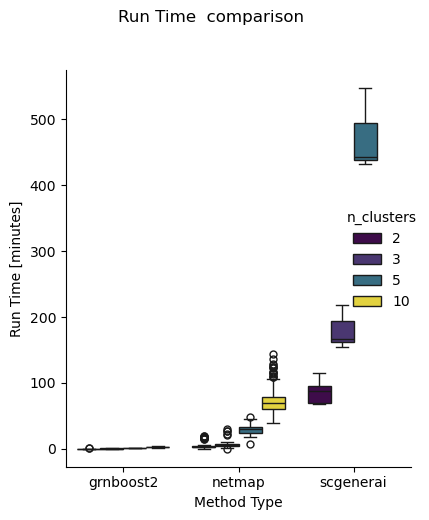

In [10]:
g = sns.catplot(
    data=all_times,
    x='method',
    y='runtime_minutes',
    hue='n_clusters',        # Create separate columns/panels for each unique 'config'
    kind='box',          # Specify the plot type as a boxplot
    height=5,            # Height of each facet
    aspect=0.7,          # Aspect ratio of each facet
    palette='viridis',   # Color palette
    sharey=True          # Ensure all panels share the same Y-axis scale
)


    
g.fig.suptitle('Run Time  comparison', y=1.03)

# Adjust axis labels for clarity
g.set_axis_labels("Method Type", "Runtime [minutes]")

# Rotate x-axis labels if they are too long
g.set_xticklabels(rotation=0, ha="center")

# Tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()